In [1]:
import sys

import polars as pl
import torch
import os
import glob

from modeling_module.data_loader.MultiPartDataModule import MultiPartDataModule
from modeling_module.data_loader.MultiPartExoDataModule import MultiPartExoDataModule

'''
pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128
https://developer.nvidia.com/cuda-12-8-0-download-archive
'''

MAC_DIR = '/Users/igwanhyeong/PycharmProjects/data_research/raw_data/'
WINDOW_DIR = 'C:/Users/USER/PycharmProjects/research/raw_data/'

if sys.platform == 'win32':
    DIR = WINDOW_DIR
    print(torch.cuda.is_available())
    print(torch.cuda.device_count())
    print(torch.version.cuda)
    print(torch.__version__)
    print(torch.cuda.get_device_name(0))
    print(torch.__version__)
else:
    DIR = MAC_DIR
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

save_dir = DIR + 'fit/model_validation'

if os.path.exists(save_dir):
    files = glob.glob(os.path.join(save_dir, "*.pt"))
    print(f"Deleting {len(files)} old checkpoint files...")
    for f in files:
        try:
            os.remove(f)
        except Exception as e:
            print(f"Error deleting {f}: {e}")
else:
    os.makedirs(save_dir, exist_ok=True)

print("Clean up complete.")


True
1
12.8
2.9.0.dev20250716+cu128
NVIDIA GeForce RTX 5080
2.9.0.dev20250716+cu128
Deleting 0 old checkpoint files...
Clean up complete.


In [2]:
from modeling_module.utils.date_util import DateUtil

ETT1 = (pl.read_csv(DIR + 'csv/ETTm1.csv'))
ETT1_sample = (ETT1
               .select(['date', 'HUFL'])
               .with_columns(pl.lit('A').alias('unique_id'))
               .with_columns(pl.col('date').map_elements(DateUtil.parse_to_yyyymmddhh, return_dtype = pl.Int64).alias('date'))
               )
ETT1_sample

date,HUFL,unique_id
i64,f64,str
2016070100,5.827,"""A"""
2016070100,5.76,"""A"""
2016070100,5.76,"""A"""
2016070100,5.76,"""A"""
2016070101,5.693,"""A"""
…,…,…
2018062618,9.31,"""A"""
2018062619,10.114,"""A"""
2018062619,10.784,"""A"""


In [3]:
# import matplotlib.pyplot as plt
# plt.figure(figsize = (18, 6))
# plt.plot(ETT1['date'], ETT1['HUFL'])
# plt.xticks(rotation = 90, fontsize = 8)
# plt.title('ETT Dataset - Weekly Mean OT', fontsize = 16)
# plt.xlabel('Year-Week', fontsize = 12)
# plt.ylabel('Mean OT', fontsize = 12)
# plt.grid(True, linestyle = '--', alpha = 0.4)
#
# plt.tight_layout()
# plt.show()

In [4]:
plan_yyyyww = 201801
lookback = 72
horizon = 24

data_module = MultiPartExoDataModule(
    ETT1_sample,
    part_col = 'unique_id',
    date_col = 'date',
    qty_col = 'HUFL',
    lookback = lookback,
    horizon = horizon,
    batch_size = 256,
    freq = 'hourly',
    shuffle = False
)

train_loader = data_module.get_train_loader()
val_loader = data_module.get_val_loader()

In [5]:
print("len(train_dataset) =", len(data_module.train_dataset))
print("len(val_dataset)   =", len(data_module.val_dataset))

train_loader = data_module.get_train_loader()
val_loader   = data_module.get_val_loader()

print("len(train_loader) =", len(train_loader))
print("len(val_loader)   =", len(val_loader))


len(train_dataset) = 55668
len(val_dataset)   = 13917
len(train_loader) = 217
len(val_loader)   = 55


In [6]:
from modeling_module.training.model_trainers.total_train import run_total_train_monthly, run_total_train_weekly, \
    run_total_train_hourly

model_dict = run_total_train_hourly(
    train_loader,
    val_loader,
    lookback = lookback,
    horizon = horizon,
    save_dir = save_dir
)

PatchMixer Base (Hourly)
[EXO-setup] inferred E=4, model.exo_dim=4, has_head=True

[train_patchmixer] ===== Stage 1/2 =====
  - spike: OFF
  - epochs: 20 | lr=0.0001 | horizon_decay=False
[train_patchmixer] Effective TrainingConfig:
{
  "device": "cuda",
  "lookback": 72,
  "horizon": 24,
  "epochs": 20,
  "lr": 0.0001,
  "weight_decay": 0.001,
  "t_max": 40,
  "patience": 100,
  "max_grad_norm": 30.0,
  "amp_device": "cuda",
  "loss_mode": "point",
  "point_loss": "huber",
  "huber_delta": 0.8,
  "q_star": 0.5,
  "use_cost_q_star": false,
  "Cu": 1.0,
  "Co": 1.0,
  "quantiles": [
    0.1,
    0.5,
    0.9
  ],
  "use_intermittent": true,
  "alpha_zero": 3.0,
  "alpha_pos": 1.0,
  "gamma_run": 0.3,
  "cap": null,
  "use_horizon_decay": false,
  "tau_h": 0.85,
  "val_use_weights": false,
  "spike_loss": {
    "enabled": false,
    "strategy": "mix",
    "huber_delta": 0.6,
    "asym_up_weight": 1.0,
    "asym_down_weight": 8.0,
    "mad_k": 1.5,
    "w_spike": 32.0,
    "w_norm": 1.0,


In [7]:
from modeling_module.utils.checkpoint import load_model_dict
# Load
from modeling_module.models.model_builder import (
    build_patch_mixer_quantile,
    build_patchTST_base, build_patchTST_quantile, build_patch_mixer_base, build_titan_base, build_titan_lmm,
    build_titan_seq2seq,
)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

builders = {
    f"hourly_PatchMixerBase_L{lookback}_H{horizon}": build_patch_mixer_base,
    f"hourly_PatchMixerQuantile_L{lookback}_H{horizon}": build_patch_mixer_quantile,
    # f"hourly_TitanBase_L{lookback}_H{horizon}": build_titan_base,
    # f"hourly_TitanLMM_L{lookback}_H{horizon}": build_titan_lmm,
    # f"hourly_TitanSeq2Seq_L{lookback}_H{horizon}": build_titan_seq2seq,
    # f"hourly_PatchTSTBase_L{lookback}_H{horizon}": build_patchTST_base,
    # f"hourly_PatchTSTQuantile_L{lookback}_H{horizon}": build_patchTST_quantile,
}
loaded = load_model_dict(save_dir, builders, device = device)

[load] hourly_PatchMixerBase_L72_H24 ← C:/Users/USER/PycharmProjects/research/raw_data/fit/model_validation\hourly_PatchMixerBase_L72_H24.pt
{'device': 'cuda', 'lookback': 72, 'horizon': 24, 'epochs': 1, 'lr': 0.0001, 'weight_decay': 0.0001, 't_max': 10, 'patience': 50, 'max_grad_norm': 30.0, 'amp_device': 'cuda', 'loss_mode': 'point', 'point_loss': 'huber', 'huber_delta': 5.0, 'q_star': 0.5, 'use_cost_q_star': False, 'Cu': 1.0, 'Co': 1.0, 'quantiles': (0.1, 0.5, 0.9), 'use_intermittent': True, 'alpha_zero': 1.2, 'alpha_pos': 1.0, 'gamma_run': 0.6, 'cap': None, 'use_horizon_decay': False, 'tau_h': 24.0, 'val_use_weights': False, 'spike_loss': {'enabled': True, 'strategy': 'mix', 'huber_delta': 2.0, 'asym_up_weight': 2.0, 'asym_down_weight': 1.0, 'mad_k': 3.5, 'w_spike': 6.0, 'w_norm': 1.0, 'alpha_huber': 0.7, 'beta_asym': 0.3, 'mix_with_baseline': False, 'gamma_baseline': 0.2}, 'lambda_hist_scale': 0.1, 'lambda_hist_var': 0.03, 'hist_window': 12, 'anchor_last_k': 8, 'anchor_weight': 0.

[FCAST-DBG] DMS block: Hm=24, var(Hm)=1.58592, first5=[7.15285, 7.64125, 8.25376, 8.52748, 9.16164]
[FCAST-DBG] DONE: H=27, var=1.57572, first5=[7.15285, 7.64125, 8.25376, 8.52748, 9.16164]
[Q-IMS][PatchMixer QuantileModel] t=0 q10=6.02972 q50=6.94482 q90=7.87459
[Q-IMS][PatchMixer QuantileModel] t=1 q10=6.50739 q50=7.28715 q90=8.07935
[Q-IMS][PatchMixer QuantileModel] t=2 q10=6.44734 q50=7.43675 q90=8.44854
[Q-IMS][PatchMixer QuantileModel] t=3 q10=6.72125 q50=7.66478 q90=8.63435
[Q-IMS][PatchMixer QuantileModel] t=4 q10=6.83806 q50=7.95088 q90=9.08339


C:\Users\USER\python\py312\Lib\site-packages\torch\nn\init.py:566: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


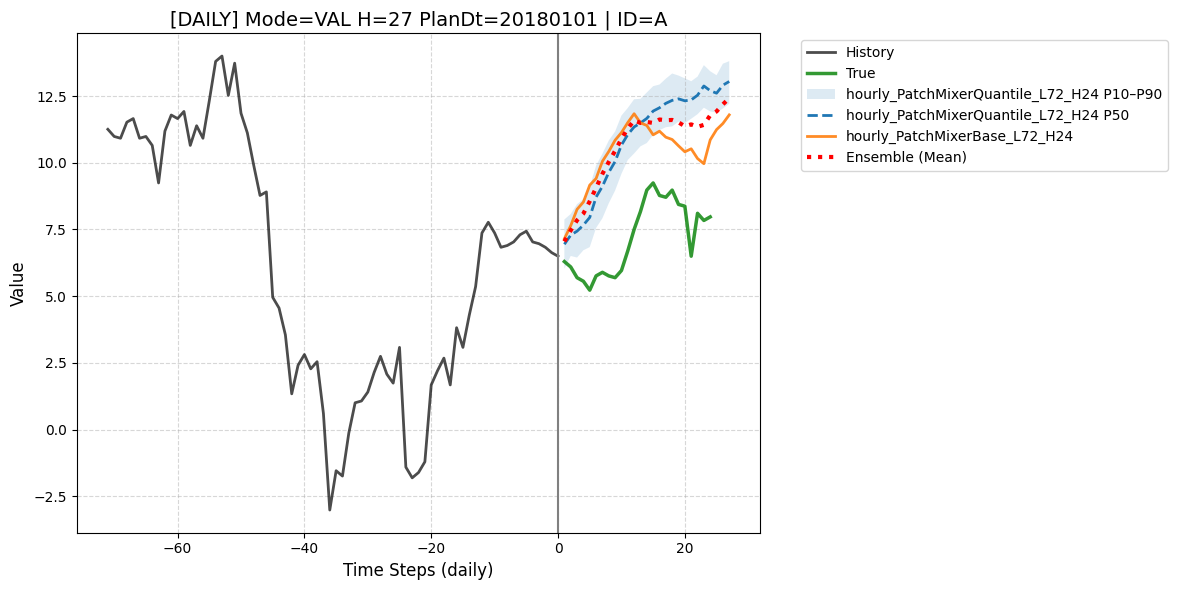

[FCAST-DBG] DMS block: Hm=24, var(Hm)=6.61186, first5=[7.95894, 8.05553, 8.48541, 8.00108, 7.96248]
[FCAST-DBG] DONE: H=27, var=6.70434, first5=[7.95894, 8.05553, 8.48541, 8.00108, 7.96248]
[Q-IMS][PatchMixer QuantileModel] t=0 q10=6.9867 q50=7.82613 q90=8.71274
[Q-IMS][PatchMixer QuantileModel] t=1 q10=7.09937 q50=7.79495 q90=8.5232
[Q-IMS][PatchMixer QuantileModel] t=2 q10=7.03226 q50=7.72173 q90=8.44001
[Q-IMS][PatchMixer QuantileModel] t=3 q10=6.5465 q50=7.5669 q90=8.59878
[Q-IMS][PatchMixer QuantileModel] t=4 q10=6.60301 q50=7.68028 q90=8.76882


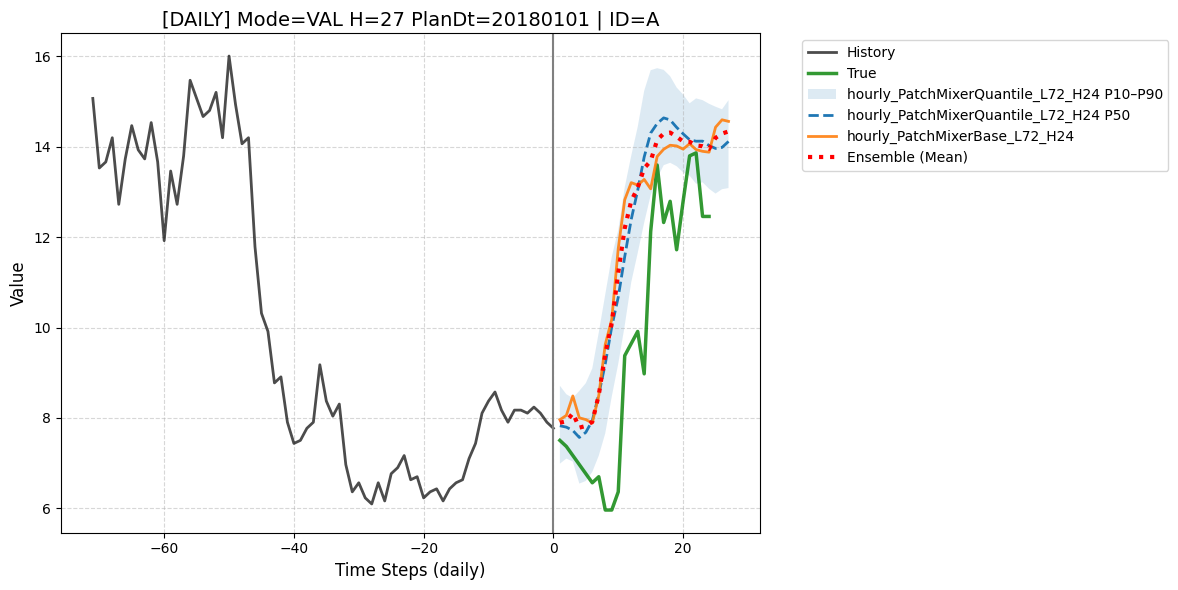

[FCAST-DBG] DMS block: Hm=24, var(Hm)=0.217914, first5=[8.9193, 8.88399, 9.23456, 9.34703, 9.45462]
[FCAST-DBG] DONE: H=27, var=0.279884, first5=[8.9193, 8.88399, 9.23456, 9.34703, 9.45462]
[Q-IMS][PatchMixer QuantileModel] t=0 q10=7.53087 q50=8.28874 q90=9.14943
[Q-IMS][PatchMixer QuantileModel] t=1 q10=7.60027 q50=8.30837 q90=9.11859
[Q-IMS][PatchMixer QuantileModel] t=2 q10=7.45035 q50=8.345 q90=9.36969
[Q-IMS][PatchMixer QuantileModel] t=3 q10=6.99424 q50=7.70278 q90=8.53193
[Q-IMS][PatchMixer QuantileModel] t=4 q10=7.11999 q50=7.77442 q90=8.52226


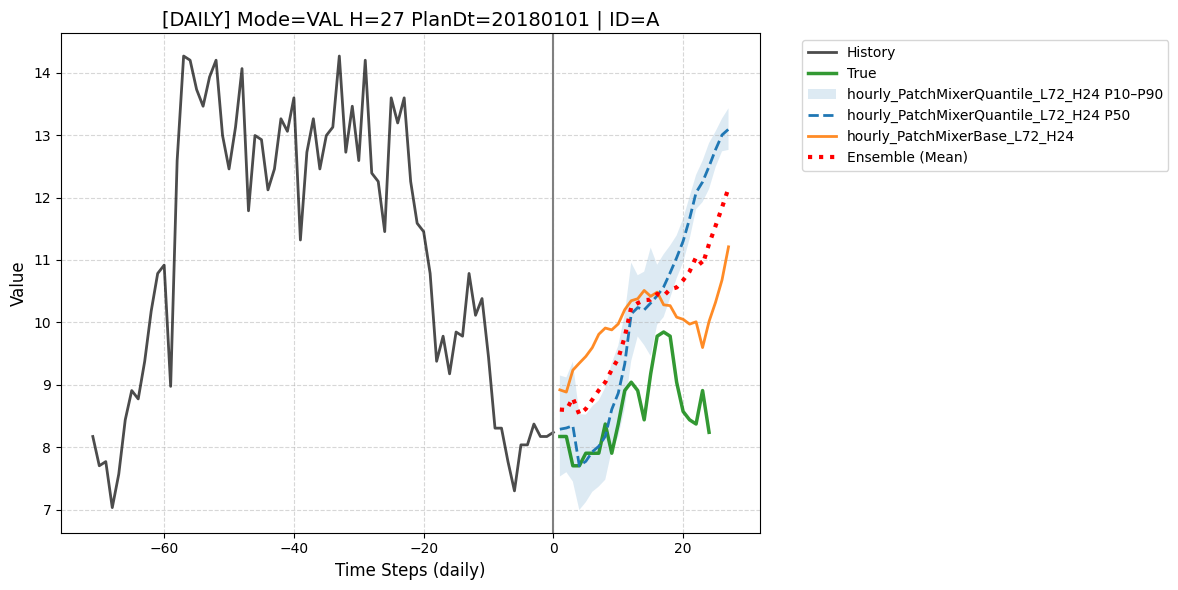

[FCAST-DBG] DMS block: Hm=24, var(Hm)=1.8418, first5=[12.6819, 13.2996, 13.5029, 13.5088, 13.8373]
[FCAST-DBG] DONE: H=27, var=2.8619, first5=[12.6819, 13.2996, 13.5029, 13.5088, 13.8373]
[Q-IMS][PatchMixer QuantileModel] t=0 q10=11.7531 q50=12.5153 q90=13.2799
[Q-IMS][PatchMixer QuantileModel] t=1 q10=11.8665 q50=12.6743 q90=13.4798
[Q-IMS][PatchMixer QuantileModel] t=2 q10=11.6291 q50=12.4682 q90=13.306
[Q-IMS][PatchMixer QuantileModel] t=3 q10=11.4762 q50=12.4354 q90=13.3954
[Q-IMS][PatchMixer QuantileModel] t=4 q10=11.695 q50=12.8294 q90=13.9725


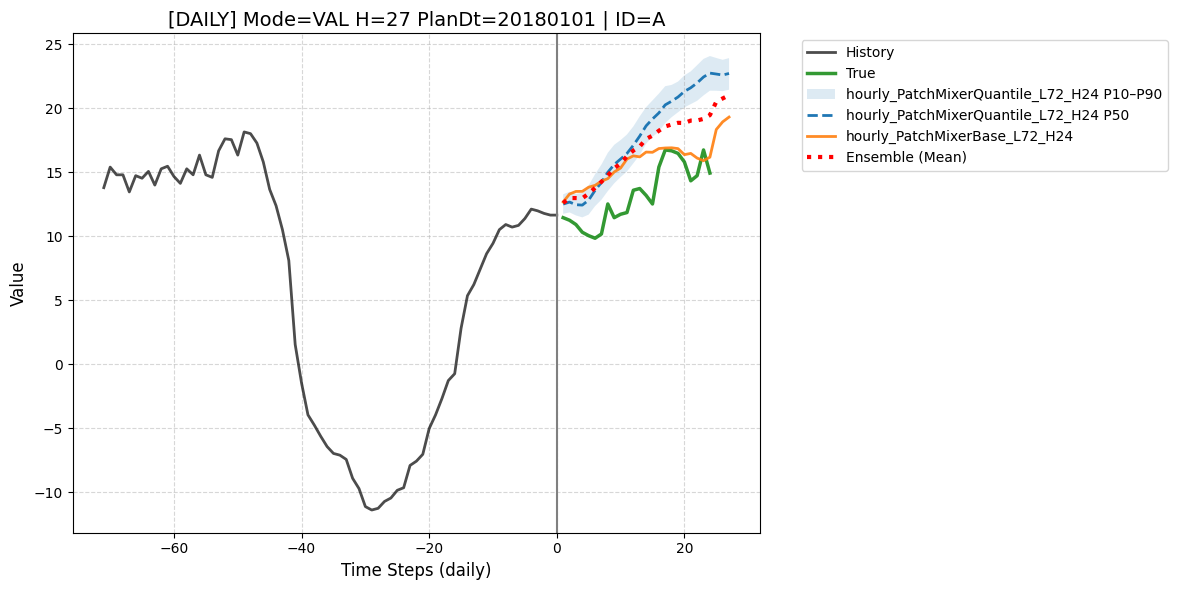

[FCAST-DBG] DMS block: Hm=24, var(Hm)=1.03804, first5=[13.3134, 13.4458, 13.5825, 13.6331, 13.6496]
[FCAST-DBG] DONE: H=27, var=0.98034, first5=[13.3134, 13.4458, 13.5825, 13.6331, 13.6496]
[Q-IMS][PatchMixer QuantileModel] t=0 q10=12.1502 q50=12.8447 q90=13.5182
[Q-IMS][PatchMixer QuantileModel] t=1 q10=12.0349 q50=12.7134 q90=13.3937
[Q-IMS][PatchMixer QuantileModel] t=2 q10=12.227 q50=12.8898 q90=13.5463
[Q-IMS][PatchMixer QuantileModel] t=3 q10=12.766 q50=13.1784 q90=13.5886
[Q-IMS][PatchMixer QuantileModel] t=4 q10=12.388 q50=13.6409 q90=14.8111


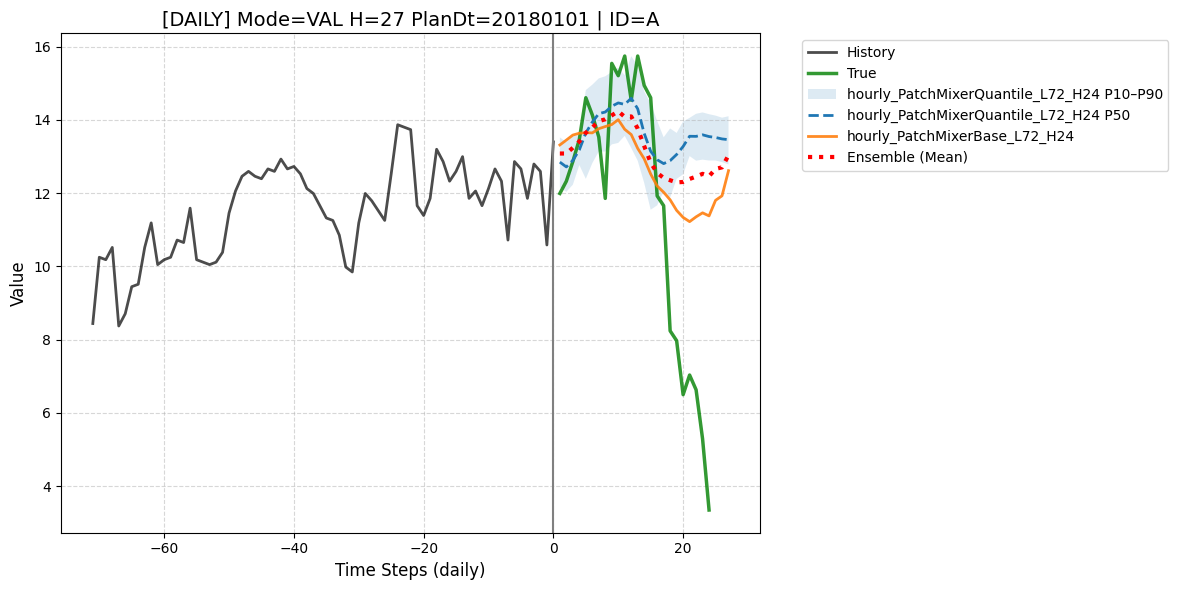

[FCAST-DBG] DMS block: Hm=24, var(Hm)=0.2524, first5=[13.1307, 13.6233, 13.7177, 13.7312, 14.1634]
[FCAST-DBG] DONE: H=27, var=0.262594, first5=[13.1307, 13.6233, 13.7177, 13.7312, 14.1634]
[Q-IMS][PatchMixer QuantileModel] t=0 q10=11.0225 q50=12.0305 q90=12.93
[Q-IMS][PatchMixer QuantileModel] t=1 q10=10.9272 q50=12.0631 q90=13.0228
[Q-IMS][PatchMixer QuantileModel] t=2 q10=11.4284 q50=12.3266 q90=13.0978
[Q-IMS][PatchMixer QuantileModel] t=3 q10=11.4416 q50=12.263 q90=12.97
[Q-IMS][PatchMixer QuantileModel] t=4 q10=11.3294 q50=12.2761 q90=13.0905


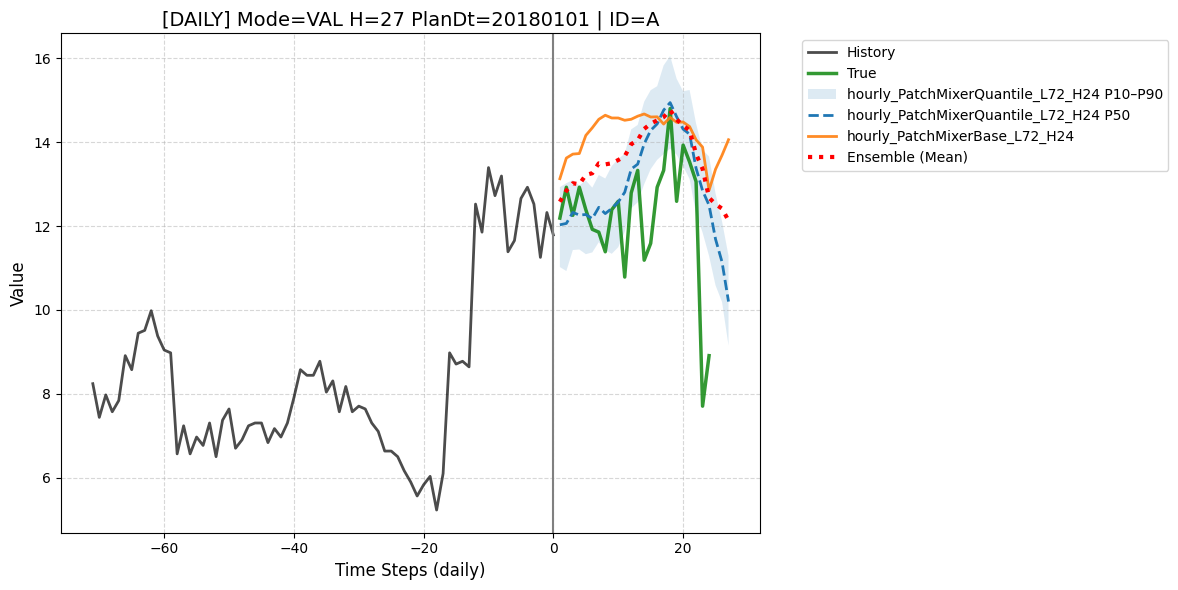

[FCAST-DBG] DMS block: Hm=24, var(Hm)=5.84307, first5=[6.17071, 7.96294, 10.105, 11.1392, 12.5167]
[FCAST-DBG] DONE: H=27, var=6.9, first5=[6.17071, 7.96294, 10.105, 11.1392, 12.5167]
[Q-IMS][PatchMixer QuantileModel] t=0 q10=1.72904 q50=4.44479 q90=7.24203
[Q-IMS][PatchMixer QuantileModel] t=1 q10=3.66441 q50=5.96681 q90=8.39344
[Q-IMS][PatchMixer QuantileModel] t=2 q10=4.35231 q50=6.65252 q90=9.12097
[Q-IMS][PatchMixer QuantileModel] t=3 q10=5.72838 q50=7.64294 q90=9.70291
[Q-IMS][PatchMixer QuantileModel] t=4 q10=7.04377 q50=8.88702 q90=10.8357


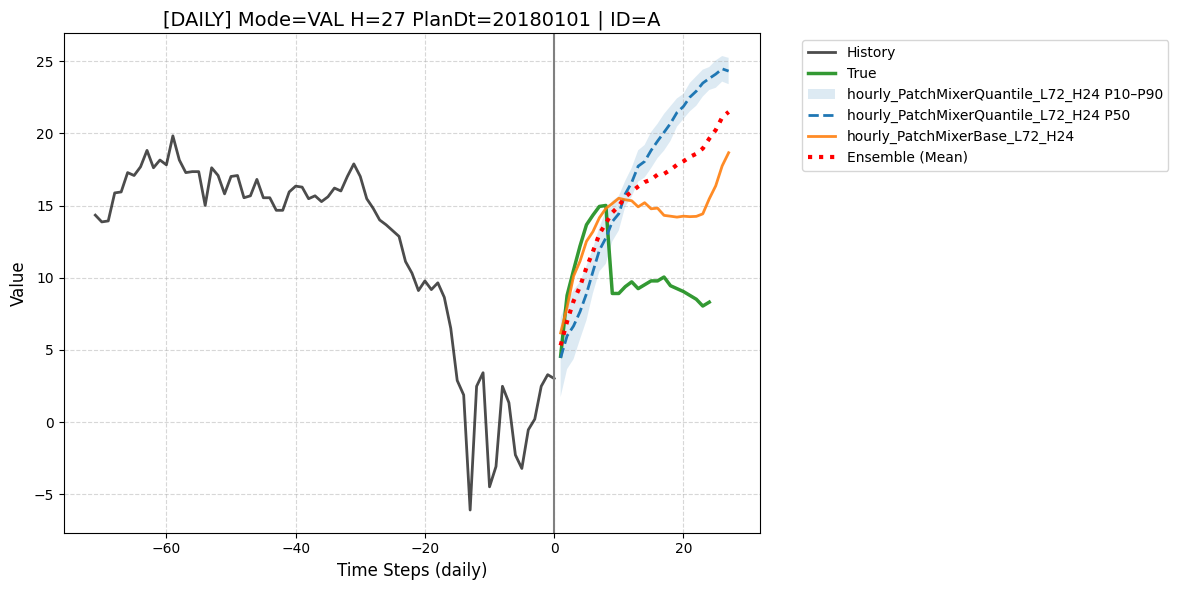

[FCAST-DBG] DMS block: Hm=24, var(Hm)=0.343394, first5=[5.84562, 6.49393, 6.43332, 6.27415, 6.61761]
[FCAST-DBG] DONE: H=27, var=1.54794, first5=[5.84562, 6.49393, 6.43332, 6.27415, 6.61761]
[Q-IMS][PatchMixer QuantileModel] t=0 q10=4.36724 q50=5.18161 q90=6.01183
[Q-IMS][PatchMixer QuantileModel] t=1 q10=4.74407 q50=5.58183 q90=6.4265
[Q-IMS][PatchMixer QuantileModel] t=2 q10=5.17626 q50=6.00286 q90=6.82802
[Q-IMS][PatchMixer QuantileModel] t=3 q10=5.46872 q50=6.30956 q90=7.13554
[Q-IMS][PatchMixer QuantileModel] t=4 q10=5.43764 q50=6.34631 q90=7.22256


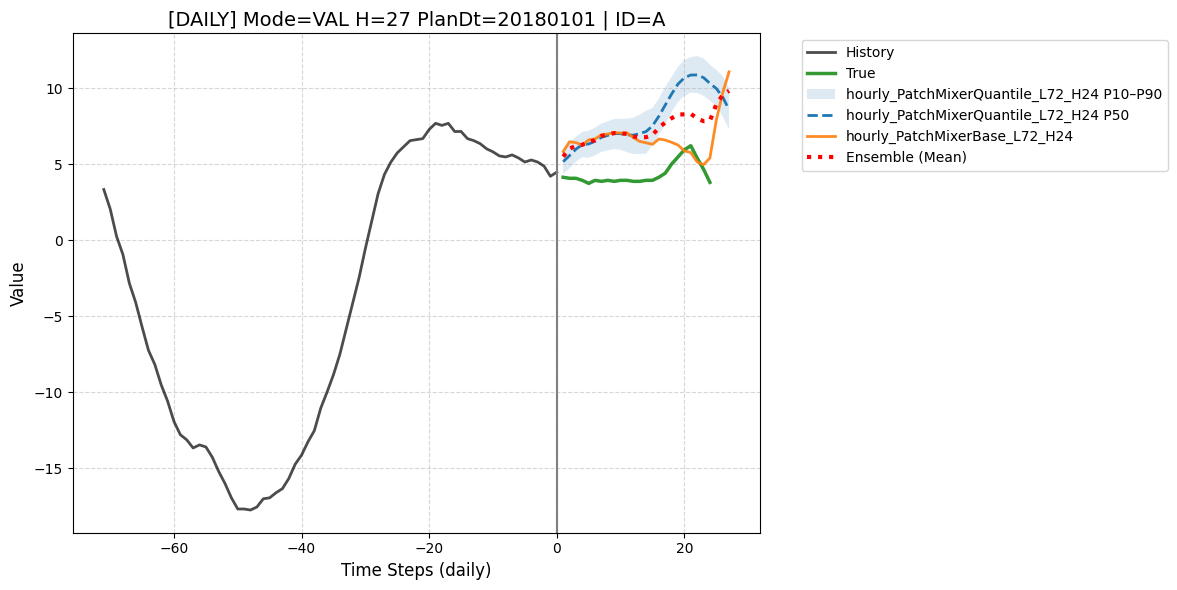

[FCAST-DBG] DMS block: Hm=24, var(Hm)=0.751508, first5=[12.6061, 12.771, 13.6108, 13.9143, 14.3301]
[FCAST-DBG] DONE: H=27, var=0.944537, first5=[12.6061, 12.771, 13.6108, 13.9143, 14.3301]
[Q-IMS][PatchMixer QuantileModel] t=0 q10=12.0463 q50=12.8341 q90=13.6508
[Q-IMS][PatchMixer QuantileModel] t=1 q10=11.9616 q50=12.8244 q90=13.7256
[Q-IMS][PatchMixer QuantileModel] t=2 q10=12.1838 q50=13.0482 q90=13.9555
[Q-IMS][PatchMixer QuantileModel] t=3 q10=12.5307 q50=13.3378 q90=14.1852
[Q-IMS][PatchMixer QuantileModel] t=4 q10=12.3928 q50=13.2264 q90=14.1018


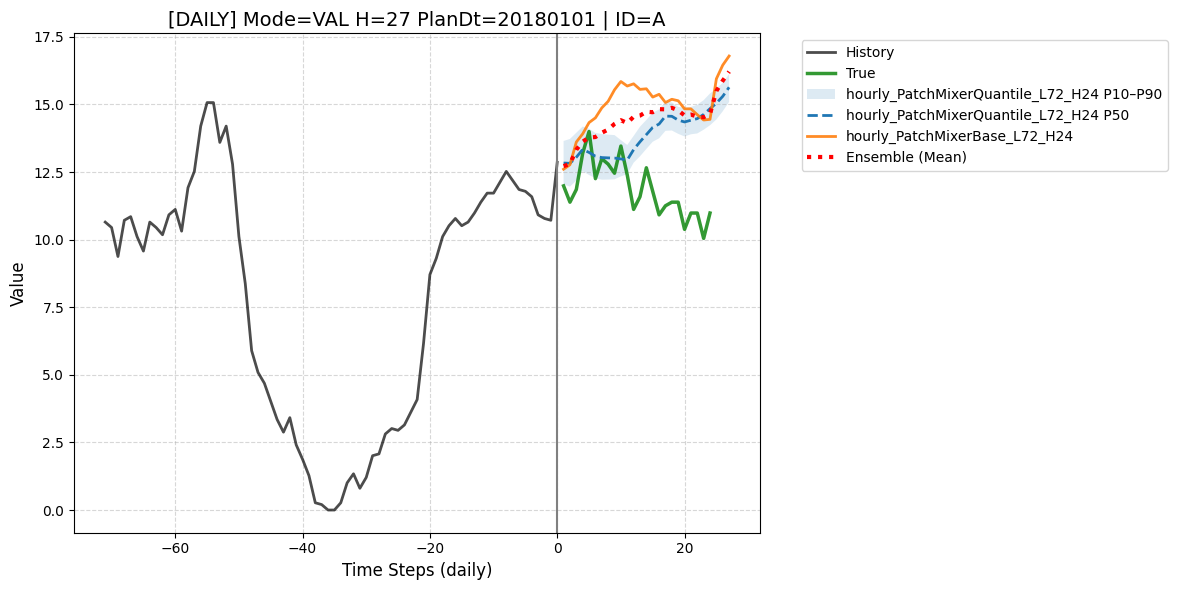

[FCAST-DBG] DMS block: Hm=24, var(Hm)=0.122148, first5=[13.4578, 13.6752, 14.3017, 14.5441, 14.6077]
[FCAST-DBG] DONE: H=27, var=0.127828, first5=[13.4578, 13.6752, 14.3017, 14.5441, 14.6077]
[Q-IMS][PatchMixer QuantileModel] t=0 q10=11.5846 q50=12.7858 q90=13.987
[Q-IMS][PatchMixer QuantileModel] t=1 q10=11.9381 q50=13.0142 q90=14.0984
[Q-IMS][PatchMixer QuantileModel] t=2 q10=12.227 q50=13.02 q90=13.8193
[Q-IMS][PatchMixer QuantileModel] t=3 q10=12.3253 q50=13.0855 q90=13.8463
[Q-IMS][PatchMixer QuantileModel] t=4 q10=12.1787 q50=12.9138 q90=13.6454


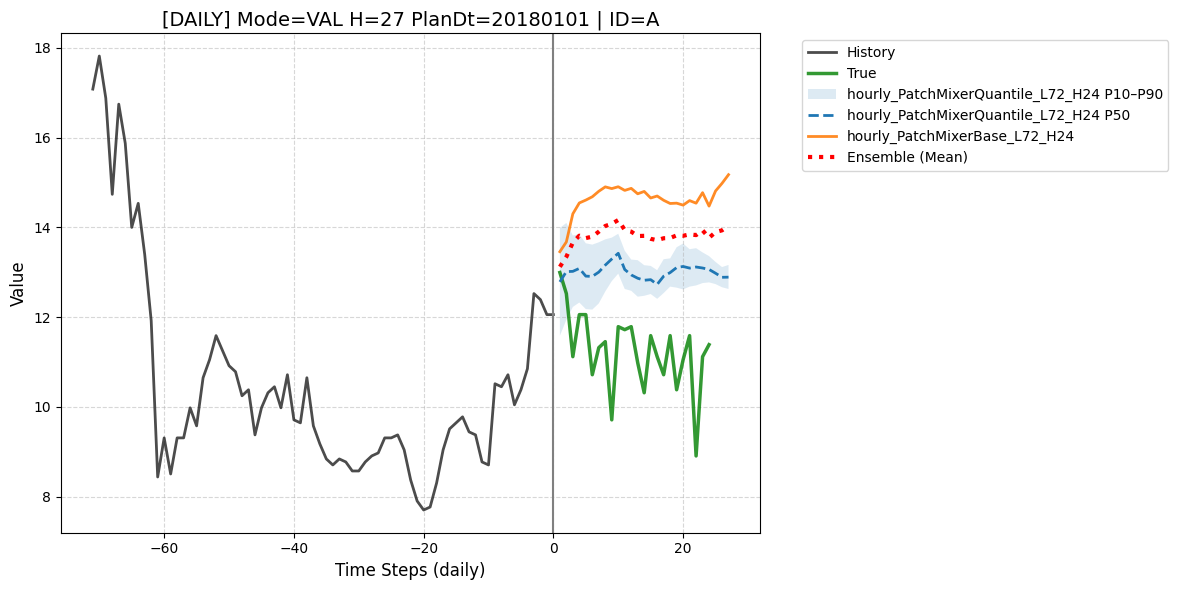

In [8]:
%load_ext autoreload
%autoreload 2

import importlib, modeling_module.utils.plot_utils as pu
import modeling_module.training.forecaster as fo
importlib.reload(pu)
importlib.reload(fo)

def my_exo_cb(start_idx: int, Hm: int, device="cuda" if torch.cuda.is_available() else "cpu"):
    # exo_dim = 2 (sin, cos)
    return fo.make_calendar_exo(start_idx, Hm, period=12, device=device)

# pu.plot_27w(
#     models=loaded,           # {"PatchMixer": pm_model, "Titan": ti_model, ...}
#     loader=val_loader,       # (xb, yb[, part_ids])
#     device="cuda" if torch.cuda.is_available() else "cpu",
#     mode="val",              # ← 검증 모드
#     max_plots=1,
#     out_dir=None,
#     show=True,
#     future_exo_cb=my_exo_cb
# )

models_for_plot = {
    name: res['model']
    for name, res in model_dict.items()
}

pu.plot_forecast(
    models=loaded,
    loader=val_loader,
    horizon=27,       # 원하는 길이
    freq='daily',     # 'daily', 'hourly' 등
    plan_dt=20180101, # Anchor 날짜 (선택)
    zoom=False        # 전체 보기
)

[FCAST-DBG] DMS block: Hm=24, var(Hm)=1.58592, first5=[7.15285, 7.64125, 8.25376, 8.52748, 9.16164]
[FCAST-DBG] DONE: H=27, var=1.57572, first5=[7.15285, 7.64125, 8.25376, 8.52748, 9.16164]
[Q-IMS][PatchMixer QuantileModel] t=0 q10=5.31282 q50=6.22793 q90=7.15769
[Q-IMS][PatchMixer QuantileModel] t=1 q10=5.2715 q50=6.06636 q90=6.87627
[Q-IMS][PatchMixer QuantileModel] t=2 q10=4.85674 q50=5.82929 q90=6.82768
[Q-IMS][PatchMixer QuantileModel] t=3 q10=4.56753 q50=5.54718 q90=6.57188
[Q-IMS][PatchMixer QuantileModel] t=4 q10=4.23314 q50=5.53981 q90=6.87395
[FCAST-DBG] DMS block: Hm=24, var(Hm)=0.0061056, first5=[6.94361, 6.70626, 6.69801, 6.58108, 6.60033]
[FCAST-DBG] DONE: H=27, var=0.124478, first5=[6.94361, 6.70626, 6.69801, 6.58108, 6.60033]
[FCAST-DBG] DMS block: Hm=24, var(Hm)=0.0537931, first5=[8.89895, 9.36487, 9.68704, 9.77578, 9.88351]
[FCAST-DBG] DONE: H=27, var=0.805992, first5=[8.89895, 9.36487, 9.68704, 9.77578, 9.88351]
[FCAST-DBG] DMS block: Hm=24, var(Hm)=0.0499157, first5

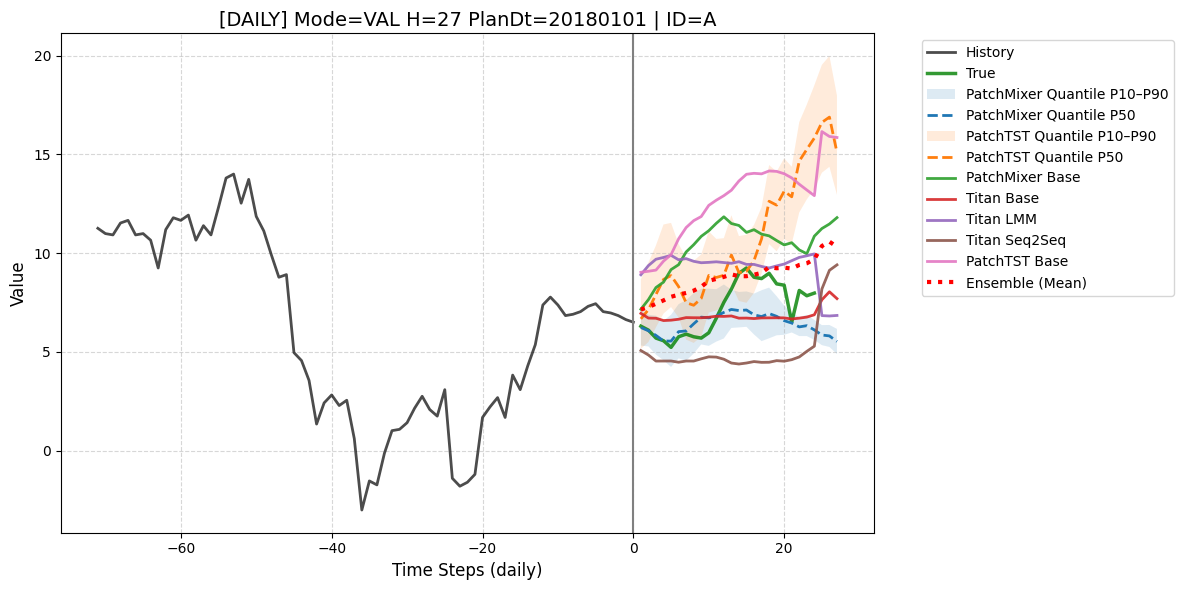

[FCAST-DBG] DMS block: Hm=24, var(Hm)=6.61186, first5=[7.95894, 8.05553, 8.48541, 8.00108, 7.96248]
[FCAST-DBG] DONE: H=27, var=6.70434, first5=[7.95894, 8.05553, 8.48541, 8.00108, 7.96248]
[Q-IMS][PatchMixer QuantileModel] t=0 q10=6.48319 q50=7.32261 q90=8.20923
[Q-IMS][PatchMixer QuantileModel] t=1 q10=6.16409 q50=6.88456 q90=7.6411
[Q-IMS][PatchMixer QuantileModel] t=2 q10=5.64734 q50=6.41609 q90=7.20715
[Q-IMS][PatchMixer QuantileModel] t=3 q10=4.78915 q50=5.88846 q90=7.00228
[Q-IMS][PatchMixer QuantileModel] t=4 q10=4.30524 q50=5.53391 q90=6.78485
[FCAST-DBG] DMS block: Hm=24, var(Hm)=0.0524617, first5=[10.7987, 11.1407, 11.4114, 11.5057, 11.5791]
[FCAST-DBG] DONE: H=27, var=0.205813, first5=[10.7987, 11.1407, 11.4114, 11.5057, 11.5791]
[FCAST-DBG] DMS block: Hm=24, var(Hm)=0.048881, first5=[9.91755, 10.3925, 10.6917, 10.8114, 10.8225]
[FCAST-DBG] DONE: H=27, var=0.265103, first5=[9.91755, 10.3925, 10.6917, 10.8114, 10.8225]
[FCAST-DBG] DMS block: Hm=24, var(Hm)=0.0662176, first5=

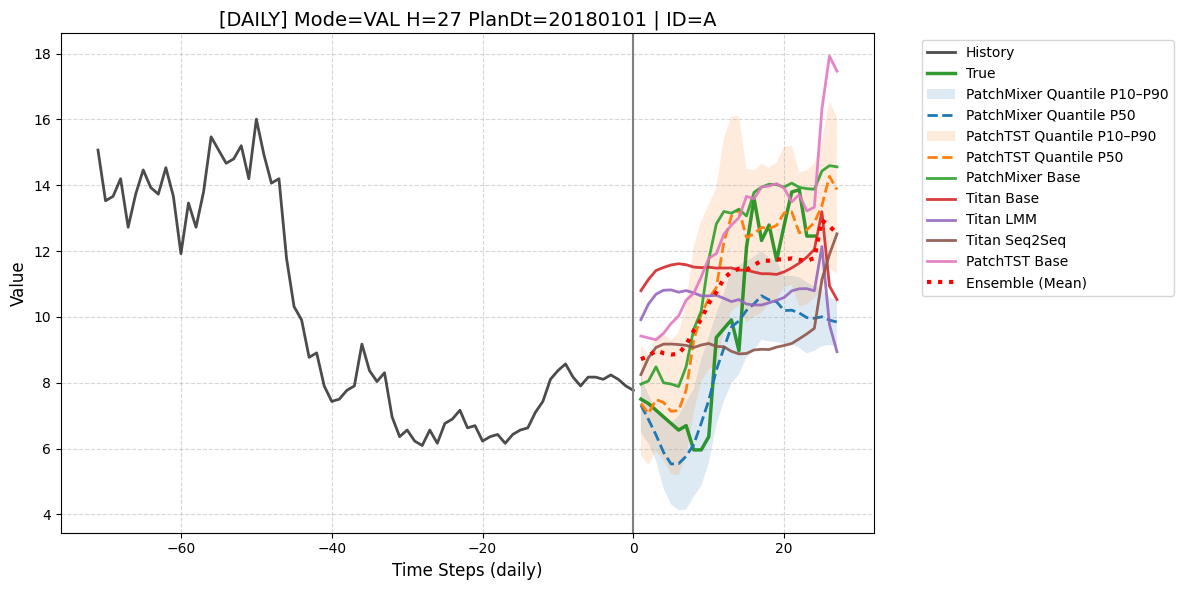

[FCAST-DBG] DMS block: Hm=24, var(Hm)=0.217914, first5=[8.9193, 8.88399, 9.23456, 9.34703, 9.45462]
[FCAST-DBG] DONE: H=27, var=0.279884, first5=[8.9193, 8.88399, 9.23456, 9.34703, 9.45462]
[Q-IMS][PatchMixer QuantileModel] t=0 q10=7.18976 q50=7.94762 q90=8.80831
[Q-IMS][PatchMixer QuantileModel] t=1 q10=7.00302 q50=7.72955 q90=8.56297
[Q-IMS][PatchMixer QuantileModel] t=2 q10=6.78089 q50=7.64069 q90=8.63245
[Q-IMS][PatchMixer QuantileModel] t=3 q10=6.25785 q50=6.95096 q90=7.76596
[Q-IMS][PatchMixer QuantileModel] t=4 q10=6.30073 q50=7.00037 q90=7.80606
[FCAST-DBG] DMS block: Hm=24, var(Hm)=0.00198212, first5=[9.54738, 9.56212, 9.61773, 9.60196, 9.61526]
[FCAST-DBG] DONE: H=27, var=0.446821, first5=[9.54738, 9.56212, 9.61773, 9.60196, 9.61526]
[FCAST-DBG] DMS block: Hm=24, var(Hm)=0.0273181, first5=[8.42052, 8.88556, 9.11518, 9.15652, 9.20575]
[FCAST-DBG] DONE: H=27, var=0.643873, first5=[8.42052, 8.88556, 9.11518, 9.15652, 9.20575]
[FCAST-DBG] DMS block: Hm=24, var(Hm)=0.0218155, firs

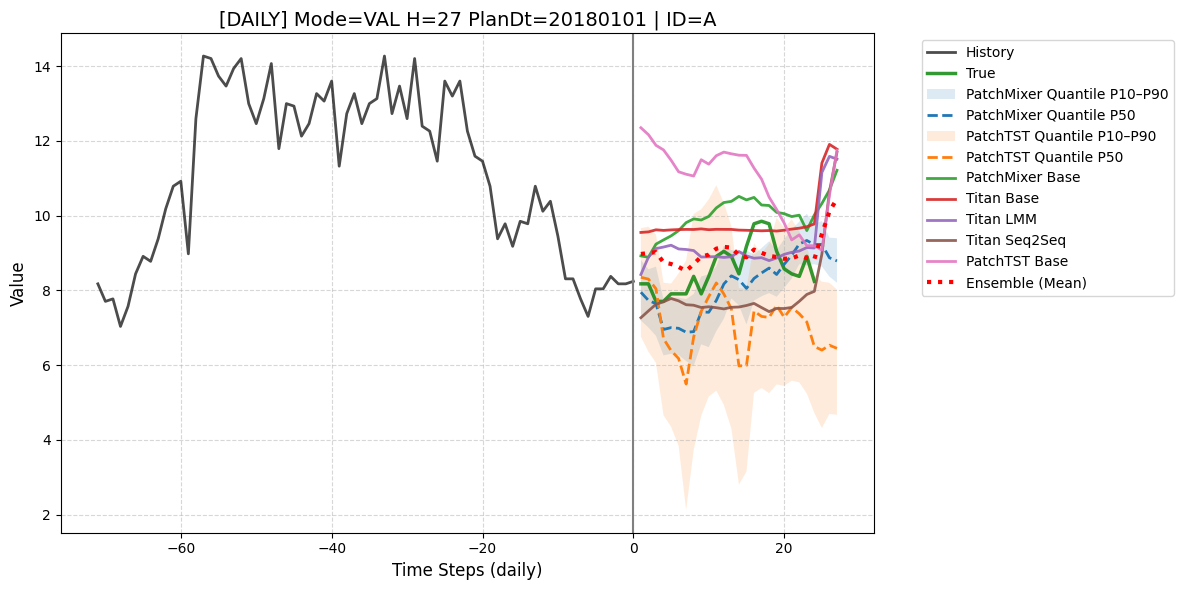

[FCAST-DBG] DMS block: Hm=24, var(Hm)=1.8418, first5=[12.6819, 13.2996, 13.5029, 13.5088, 13.8373]
[FCAST-DBG] DONE: H=27, var=2.8619, first5=[12.6819, 13.2996, 13.5029, 13.5088, 13.8373]
[Q-IMS][PatchMixer QuantileModel] t=0 q10=10.215 q50=10.9772 q90=11.7419
[Q-IMS][PatchMixer QuantileModel] t=1 q10=9.26706 q50=10.107 q90=10.9502
[Q-IMS][PatchMixer QuantileModel] t=2 q10=8.01506 q50=8.94663 q90=9.88589
[Q-IMS][PatchMixer QuantileModel] t=3 q10=6.86008 q50=7.99298 q90=9.14224
[Q-IMS][PatchMixer QuantileModel] t=4 q10=6.29502 q50=7.64276 q90=9.01948
[FCAST-DBG] DMS block: Hm=24, var(Hm)=0.0559146, first5=[10.0605, 9.56334, 9.61222, 9.3828, 9.33266]
[FCAST-DBG] DONE: H=27, var=0.238779, first5=[10.0605, 9.56334, 9.61222, 9.3828, 9.33266]
[FCAST-DBG] DMS block: Hm=24, var(Hm)=0.020426, first5=[11.128, 11.2998, 11.4535, 11.5299, 11.599]
[FCAST-DBG] DONE: H=27, var=0.666496, first5=[11.128, 11.2998, 11.4535, 11.5299, 11.599]
[FCAST-DBG] DMS block: Hm=24, var(Hm)=0.744721, first5=[3.13194, 

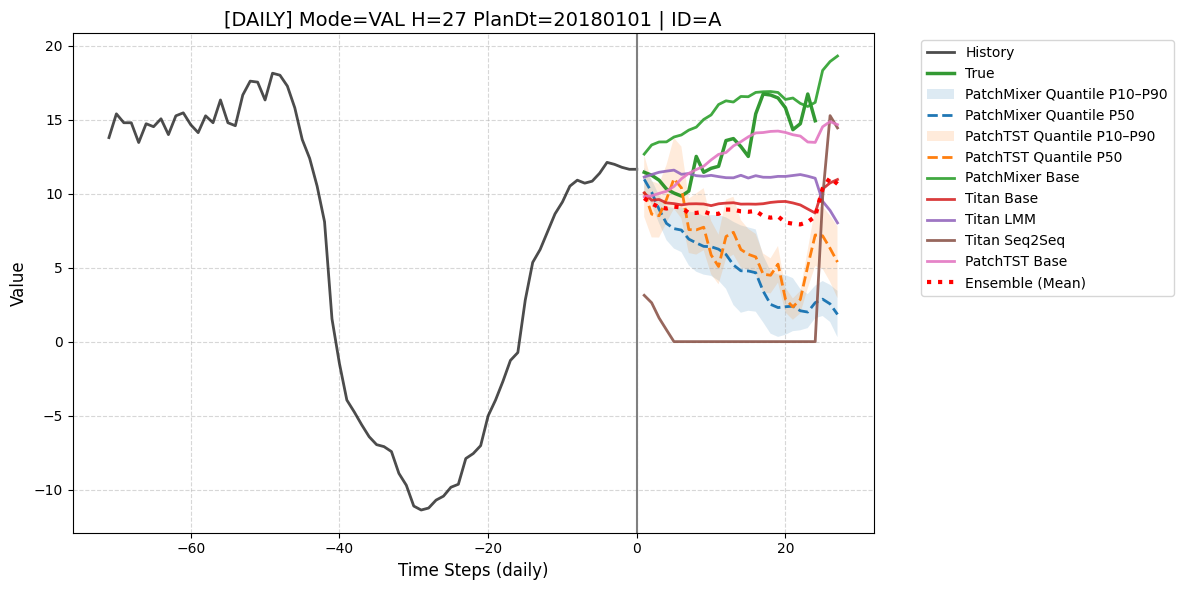

[FCAST-DBG] DMS block: Hm=24, var(Hm)=1.03804, first5=[13.3134, 13.4458, 13.5825, 13.6331, 13.6496]
[FCAST-DBG] DONE: H=27, var=0.98034, first5=[13.3134, 13.4458, 13.5825, 13.6331, 13.6496]
[Q-IMS][PatchMixer QuantileModel] t=0 q10=11.9567 q50=12.6512 q90=13.3248
[Q-IMS][PatchMixer QuantileModel] t=1 q10=11.6788 q50=12.3461 q90=13.0186
[Q-IMS][PatchMixer QuantileModel] t=2 q10=11.7295 q50=12.3746 q90=13.0222
[Q-IMS][PatchMixer QuantileModel] t=3 q10=12.013 q50=12.4473 q90=12.8773
[Q-IMS][PatchMixer QuantileModel] t=4 q10=11.6962 q50=12.6295 q90=13.5455
[FCAST-DBG] DMS block: Hm=24, var(Hm)=0.000318259, first5=[13.2922, 13.2665, 13.2712, 13.2658, 13.2768]
[FCAST-DBG] DONE: H=27, var=0.00405896, first5=[13.2922, 13.2665, 13.2712, 13.2658, 13.2768]
[FCAST-DBG] DMS block: Hm=24, var(Hm)=0.00201719, first5=[12.7138, 12.8264, 12.8897, 12.8929, 12.9174]
[FCAST-DBG] DONE: H=27, var=0.00307708, first5=[12.7138, 12.8264, 12.8897, 12.8929, 12.9174]
[FCAST-DBG] DMS block: Hm=24, var(Hm)=0.00168119

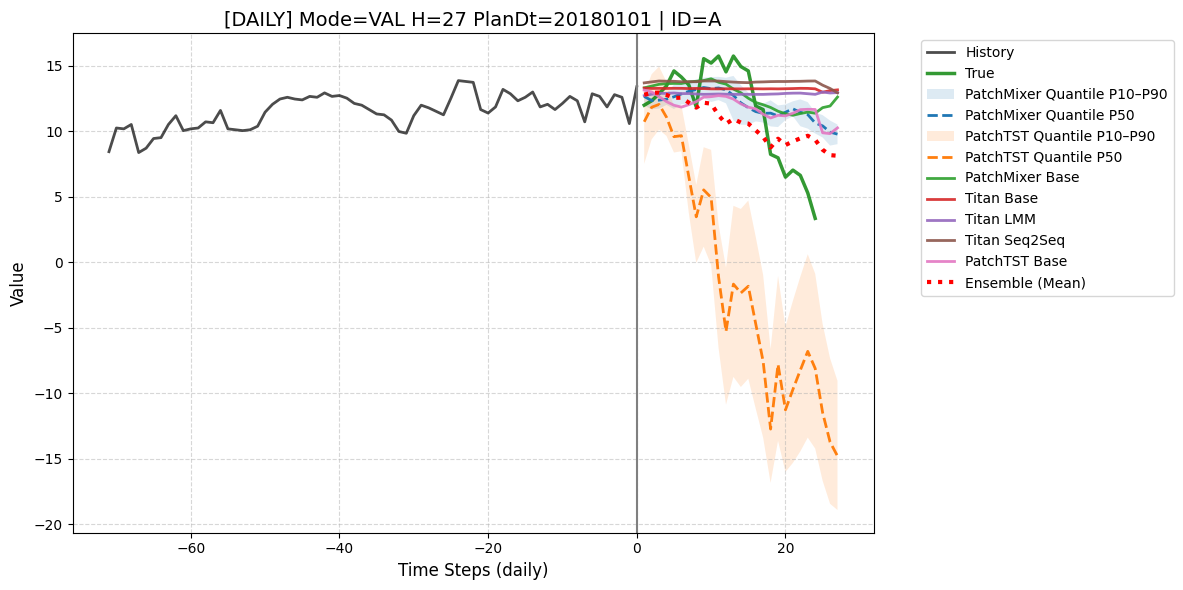

[FCAST-DBG] DMS block: Hm=24, var(Hm)=0.2524, first5=[13.1307, 13.6233, 13.7177, 13.7312, 14.1634]
[FCAST-DBG] DONE: H=27, var=0.262594, first5=[13.1307, 13.6233, 13.7177, 13.7312, 14.1634]
[Q-IMS][PatchMixer QuantileModel] t=0 q10=10.7036 q50=11.7116 q90=12.611
[Q-IMS][PatchMixer QuantileModel] t=1 q10=10.407 q50=11.5691 q90=12.5454
[Q-IMS][PatchMixer QuantileModel] t=2 q10=10.7479 q50=11.6963 q90=12.5026
[Q-IMS][PatchMixer QuantileModel] t=3 q10=10.6538 q50=11.5319 q90=12.2777
[Q-IMS][PatchMixer QuantileModel] t=4 q10=10.4312 q50=11.4502 q90=12.3124
[FCAST-DBG] DMS block: Hm=24, var(Hm)=0.00931306, first5=[12.7188, 12.8075, 12.8947, 12.9782, 13.0084]
[FCAST-DBG] DONE: H=27, var=0.0302009, first5=[12.7188, 12.8075, 12.8947, 12.9782, 13.0084]
[FCAST-DBG] DMS block: Hm=24, var(Hm)=0.0112983, first5=[12.546, 12.7929, 12.9428, 13.006, 12.9759]
[FCAST-DBG] DONE: H=27, var=0.917992, first5=[12.546, 12.7929, 12.9428, 13.006, 12.9759]
[FCAST-DBG] DMS block: Hm=24, var(Hm)=0.00399421, first5=[

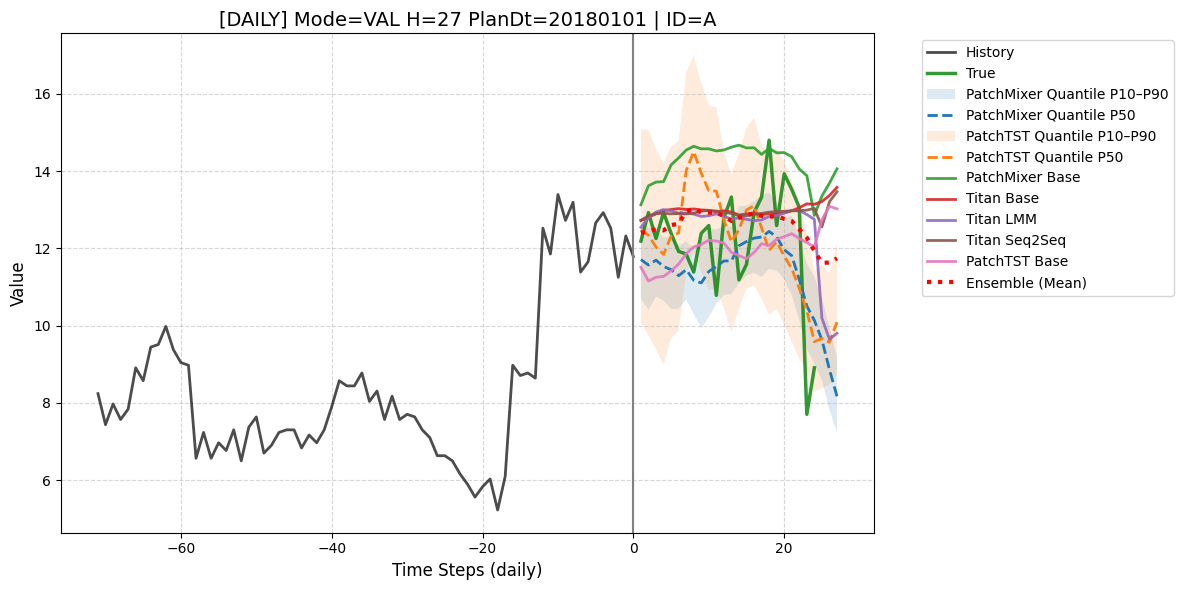

[FCAST-DBG] DMS block: Hm=24, var(Hm)=5.84307, first5=[6.17071, 7.96294, 10.105, 11.1392, 12.5167]
[FCAST-DBG] DONE: H=27, var=6.9, first5=[6.17071, 7.96294, 10.105, 11.1392, 12.5167]
[Q-IMS][PatchMixer QuantileModel] t=0 q10=0.684672 q50=3.40042 q90=6.19766
[Q-IMS][PatchMixer QuantileModel] t=1 q10=1.97791 q50=4.27635 q90=6.70713
[Q-IMS][PatchMixer QuantileModel] t=2 q10=2.15313 q50=4.42396 q90=6.88196
[Q-IMS][PatchMixer QuantileModel] t=3 q10=2.61061 q50=4.63219 q90=6.82232
[Q-IMS][PatchMixer QuantileModel] t=4 q10=3.24417 q50=5.29068 q90=7.46467
[FCAST-DBG] DMS block: Hm=24, var(Hm)=0.727187, first5=[6.56523, 7.82277, 8.9368, 9.45328, 9.42556]
[FCAST-DBG] DONE: H=27, var=1.5244, first5=[6.56523, 7.82277, 8.9368, 9.45328, 9.42556]
[FCAST-DBG] DMS block: Hm=24, var(Hm)=1.9091, first5=[0, 0, 1.9988, 3.45129, 3.86814]
[FCAST-DBG] DONE: H=27, var=6.77151, first5=[0, 0, 1.9988, 3.45129, 3.86814]
[FCAST-DBG] DMS block: Hm=24, var(Hm)=0, first5=[0, 0, 0, 0, 0]
[FCAST-DBG] DONE: H=27, var=0.

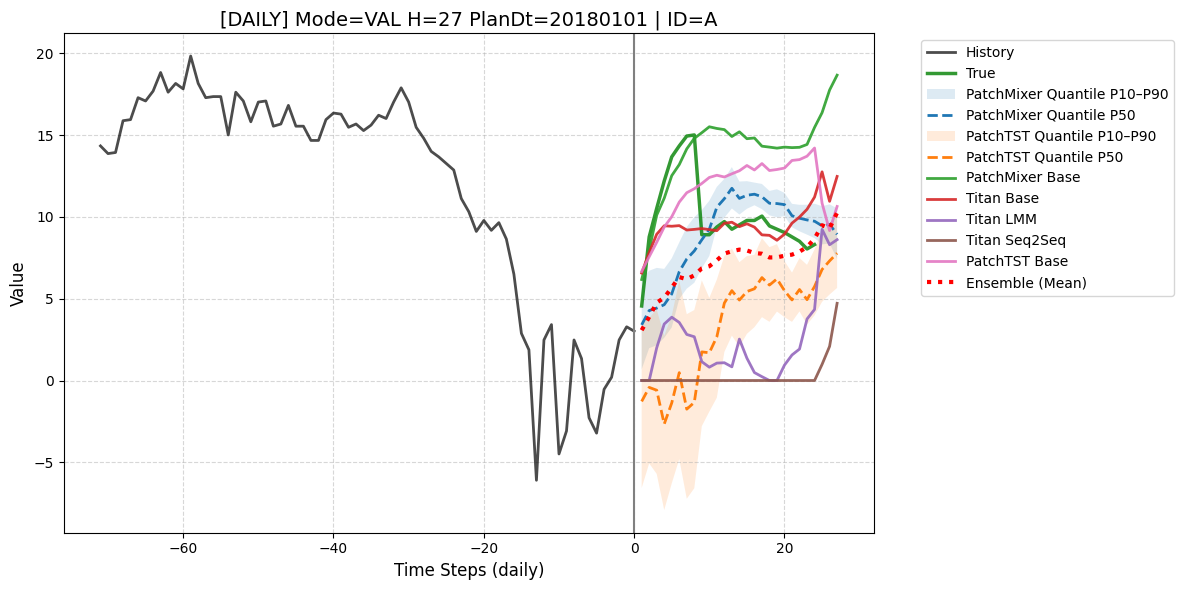

[FCAST-DBG] DMS block: Hm=24, var(Hm)=0.343394, first5=[5.84562, 6.49393, 6.43332, 6.27415, 6.61761]
[FCAST-DBG] DONE: H=27, var=1.54794, first5=[5.84562, 6.49393, 6.43332, 6.27415, 6.61761]
[Q-IMS][PatchMixer QuantileModel] t=0 q10=2.94613 q50=3.7605 q90=4.59072
[Q-IMS][PatchMixer QuantileModel] t=1 q10=2.55863 q50=3.40737 q90=4.2687
[Q-IMS][PatchMixer QuantileModel] t=2 q10=2.33384 q50=3.14459 q90=3.96358
[Q-IMS][PatchMixer QuantileModel] t=3 q10=1.99746 q50=2.77585 q90=3.55212
[Q-IMS][PatchMixer QuantileModel] t=4 q10=1.28784 q50=2.09313 q90=2.88914
[FCAST-DBG] DMS block: Hm=24, var(Hm)=0.0152771, first5=[4.34613, 4.35477, 4.61998, 4.55051, 4.75195]
[FCAST-DBG] DONE: H=27, var=1.57392, first5=[4.34613, 4.35477, 4.61998, 4.55051, 4.75195]
[FCAST-DBG] DMS block: Hm=24, var(Hm)=0.135837, first5=[0.450793, 1.26976, 1.74586, 1.78751, 1.90805]
[FCAST-DBG] DONE: H=27, var=0.227742, first5=[0.450793, 1.26976, 1.74586, 1.78751, 1.90805]
[FCAST-DBG] DMS block: Hm=24, var(Hm)=0.0479267, first5

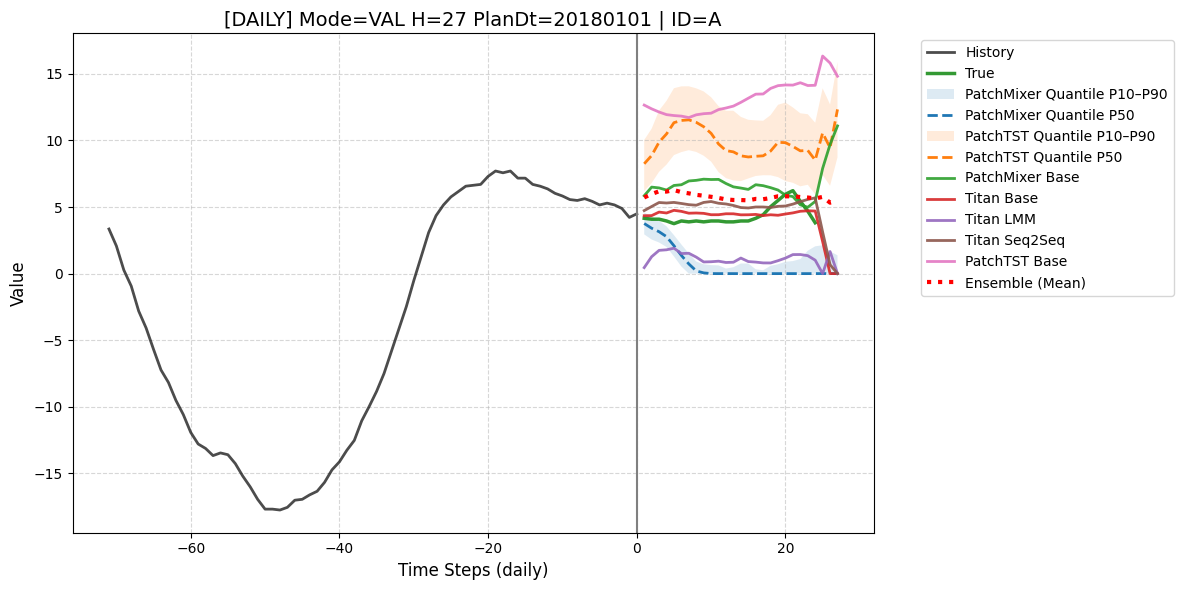

[FCAST-DBG] DMS block: Hm=24, var(Hm)=0.751508, first5=[12.6061, 12.771, 13.6108, 13.9143, 14.3301]
[FCAST-DBG] DONE: H=27, var=0.944537, first5=[12.6061, 12.771, 13.6108, 13.9143, 14.3301]
[Q-IMS][PatchMixer QuantileModel] t=0 q10=11.3471 q50=12.1348 q90=12.9516
[Q-IMS][PatchMixer QuantileModel] t=1 q10=10.7402 q50=11.6137 q90=12.5281
[Q-IMS][PatchMixer QuantileModel] t=2 q10=10.5338 q50=11.3603 q90=12.2362
[Q-IMS][PatchMixer QuantileModel] t=3 q10=10.2191 q50=10.9967 q90=11.8272
[Q-IMS][PatchMixer QuantileModel] t=4 q10=9.71613 q50=10.5064 q90=11.3532
[FCAST-DBG] DMS block: Hm=24, var(Hm)=0.00302867, first5=[12.4535, 12.3614, 12.4324, 12.3394, 12.4455]
[FCAST-DBG] DONE: H=27, var=0.345891, first5=[12.4535, 12.3614, 12.4324, 12.3394, 12.4455]
[FCAST-DBG] DMS block: Hm=24, var(Hm)=0.0149533, first5=[10.716, 10.9059, 11.0467, 11.0561, 11.0942]
[FCAST-DBG] DONE: H=27, var=0.120228, first5=[10.716, 10.9059, 11.0467, 11.0561, 11.0942]
[FCAST-DBG] DMS block: Hm=24, var(Hm)=0.00649455, first

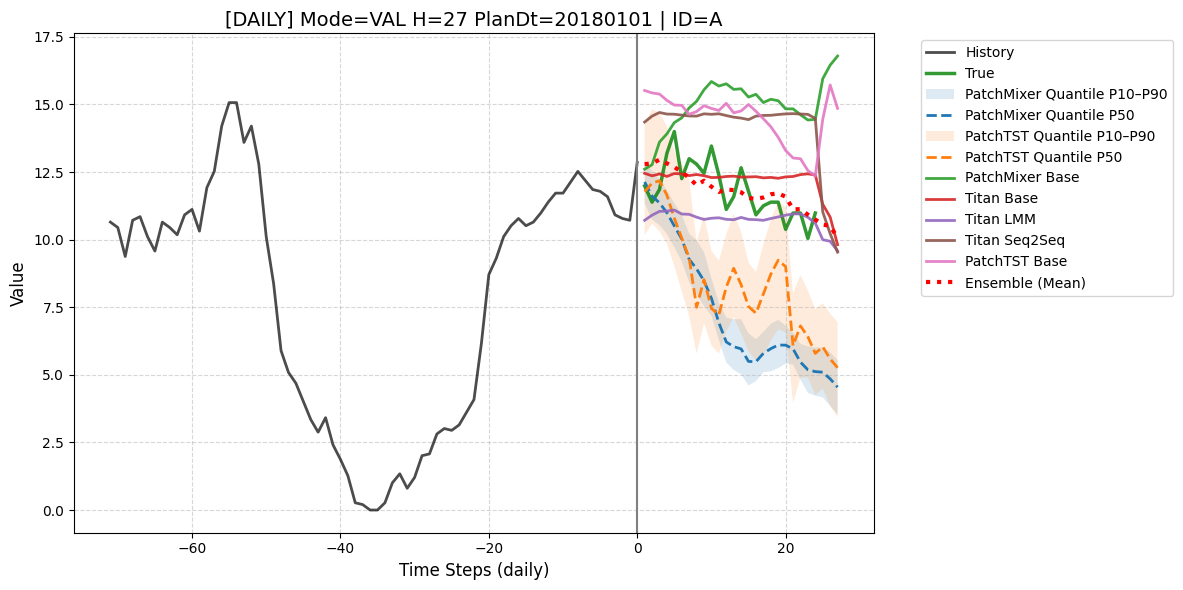

[FCAST-DBG] DMS block: Hm=24, var(Hm)=0.122148, first5=[13.4578, 13.6752, 14.3017, 14.5441, 14.6077]
[FCAST-DBG] DONE: H=27, var=0.127828, first5=[13.4578, 13.6752, 14.3017, 14.5441, 14.6077]
[Q-IMS][PatchMixer QuantileModel] t=0 q10=11.2361 q50=12.4373 q90=13.6385
[Q-IMS][PatchMixer QuantileModel] t=1 q10=11.3111 q50=12.3623 q90=13.4267
[Q-IMS][PatchMixer QuantileModel] t=2 q10=11.2127 q50=12.0759 q90=12.9414
[Q-IMS][PatchMixer QuantileModel] t=3 q10=11.0746 q50=11.8724 q90=12.6636
[Q-IMS][PatchMixer QuantileModel] t=4 q10=10.7141 q50=11.4313 q90=12.1306
[FCAST-DBG] DMS block: Hm=24, var(Hm)=0.00902222, first5=[15.0901, 15.1176, 15.151, 15.1328, 15.1809]
[FCAST-DBG] DONE: H=27, var=0.203275, first5=[15.0901, 15.1176, 15.151, 15.1328, 15.1809]
[FCAST-DBG] DMS block: Hm=24, var(Hm)=0.0187685, first5=[13.9034, 14.1573, 14.3584, 14.4692, 14.4378]
[FCAST-DBG] DONE: H=27, var=0.858096, first5=[13.9034, 14.1573, 14.3584, 14.4692, 14.4378]
[FCAST-DBG] DMS block: Hm=24, var(Hm)=0.00645354, fir

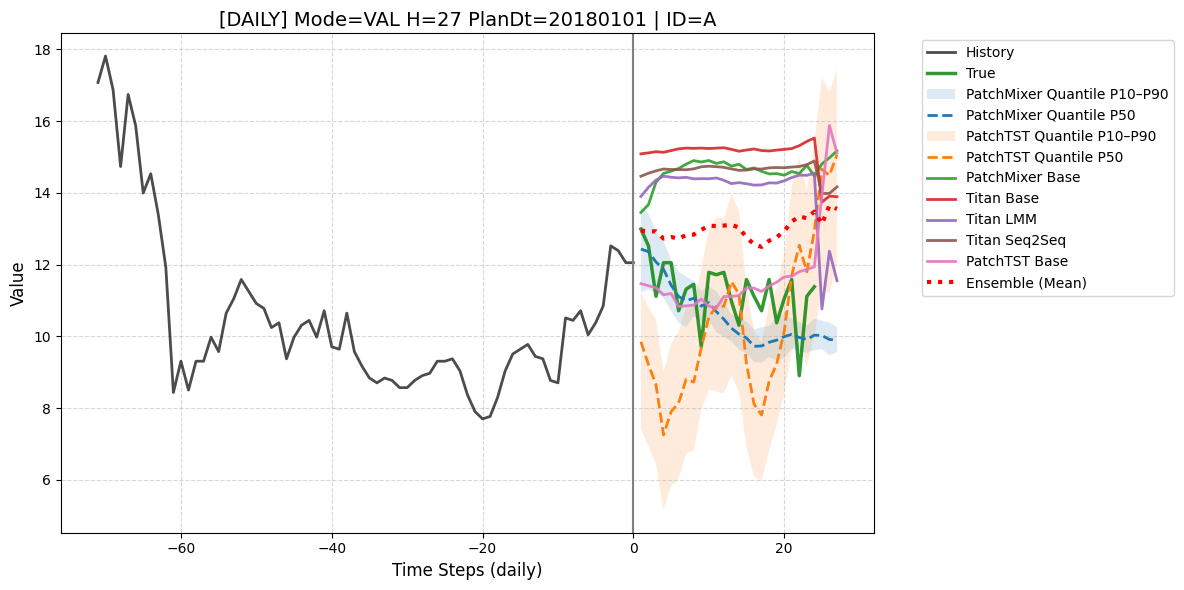

In [9]:
trained_models = {
    name: result['model']
    for name, result in model_dict.items()
}

# 플로팅 실행
pu.plot_forecast(
    models=trained_models,
    loader=val_loader,
    horizon=27,
    freq='daily',
    plan_dt=20180101,
    zoom=False,
    show=True
)